# Analysis Pipeline — UCF101 / SHViT vs Baselines

Runs the full analysis after all 6 models are trained. Everything stays on
Colab's local SSD (`/content/`) for fast iteration; final artifacts are
mirrored into `<OUT_ROOT>/Stage 4: Benchmarking and Demo/analysis/` (and
optionally to Drive) so the project root layout matches the rest of the
experiment.

Default `OUT_ROOT` is `/content/CV_Research_Paper_UCF101` (or
`/content/drive/MyDrive/CV_Research_Paper_UCF101` when Drive is mounted).


## 0. GPU check

In [1]:
import torch
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA A100-SXM4-40GB


## 1. Mount Drive (read-only access to checkpoints + dataset source)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Source paths on Drive (where Stage 2 + Stage 3 saved checkpoints and dataset)
DRIVE_OUT_ROOT      = '/content/drive/MyDrive/CV_Research_Paper_UCF101'
DRIVE_DATA          = '/content/drive/MyDrive/ucf101_data'

# Mirror the same layout locally under CV_Research_Paper_UCF101/.
OUT_ROOT            = '/content/CV_Research_Paper_UCF101'
ANALYSIS_ROOT       = f'{OUT_ROOT}/Stage 4: Benchmarking and Demo/analysis'

LOCAL_DATA          = '/content/ucf101_local'  # large(-ish), kept separate
LOCAL_CHECKPOINTS   = OUT_ROOT
LOCAL_RESULTS       = f'{ANALYSIS_ROOT}/results'
LOCAL_FIGURES       = f'{ANALYSIS_ROOT}/figures'
LOCAL_EDA           = f'{ANALYSIS_ROOT}/eda_outputs'
LOCAL_ERROR         = f'{ANALYSIS_ROOT}/error_analysis_outputs'
LOCAL_DEMO          = f'{ANALYSIS_ROOT}/demo_output'

import os
for p in [ANALYSIS_ROOT, LOCAL_RESULTS, LOCAL_FIGURES,
          LOCAL_EDA, LOCAL_ERROR, LOCAL_DEMO]:
    os.makedirs(p, exist_ok=True)

print('Output root        :', OUT_ROOT)
print('Local analysis root:', ANALYSIS_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output root        : /content/CV_Research_Paper_UCF101
Local analysis root: /content/CV_Research_Paper_UCF101/Stage 4: Benchmarking and Demo/analysis


## 2. Copy dataset to local SSD

If `/content/ucf101_local` already exists from an earlier session, this skips the copy.


In [3]:
import shutil, time

if not os.path.exists(LOCAL_DATA):
    if os.path.isdir(DRIVE_DATA):
        print('Copying UCF101 from Drive to local SSD...')
        t0 = time.time()
        shutil.copytree(DRIVE_DATA, LOCAL_DATA)
        print(f'Done in {time.time()-t0:.0f}s')
    else:
        # No cached copy in Drive — let prepare_ucf101.py download it locally.
        os.makedirs(LOCAL_DATA, exist_ok=True)
else:
    img_root = os.path.join(LOCAL_DATA, 'ucf101', 'jpg')
    if os.path.isdir(img_root):
        classes = len(os.listdir(img_root))
        print(f'Already copied — {classes} class folders present')


## 3. Copy trained checkpoints from Drive to the local output root

Mirrors the `<OUT_ROOT>/Stage 2|3/<model>/best.pth` layout that
`evaluate_all.py` and `make_figures.py` expect.


In [4]:
# Layout matches what evaluate_all.py expects:
#   <OUT_ROOT>/Stage 2: baseline models/<model>/best.pth
#   <OUT_ROOT>/Stage 3: fine-tuning SHViT/<model>/best.pth
STAGE2_LOCAL = f'{LOCAL_CHECKPOINTS}/Stage 2: baseline models'
STAGE3_LOCAL = f'{LOCAL_CHECKPOINTS}/Stage 3: fine-tuning SHViT'
os.makedirs(STAGE2_LOCAL, exist_ok=True)
os.makedirs(STAGE3_LOCAL, exist_ok=True)

DRIVE_STAGE2 = f'{DRIVE_OUT_ROOT}/Stage 2: baseline models'
DRIVE_STAGE3 = f'{DRIVE_OUT_ROOT}/Stage 3: fine-tuning SHViT'

for model in ['resnet50', 'mobilenet_v2']:
    src_dir = f'{DRIVE_STAGE2}/{model}'
    dst_dir = f'{STAGE2_LOCAL}/{model}'
    if os.path.isdir(src_dir) and not os.path.isdir(dst_dir):
        shutil.copytree(src_dir, dst_dir)
        print(f'copied {model}: {os.path.getsize(f"{dst_dir}/best.pth")/1e6:.1f} MB')
    elif os.path.isdir(dst_dir):
        print(f'{model}: already present')
    else:
        print(f'WARNING: {model} not found at {src_dir}')

for model in ['shvit_s1', 'shvit_s2', 'shvit_s3', 'shvit_s4']:
    src_dir = f'{DRIVE_STAGE3}/{model}'
    dst_dir = f'{STAGE3_LOCAL}/{model}'
    if os.path.isdir(src_dir) and not os.path.isdir(dst_dir):
        shutil.copytree(src_dir, dst_dir)
        print(f'copied {model}: {os.path.getsize(f"{dst_dir}/best.pth")/1e6:.1f} MB')
    elif os.path.isdir(dst_dir):
        print(f'{model}: already present')
    else:
        print(f'WARNING: {model} not found at {src_dir}')


resnet50: already present
mobilenet_v2: already present
shvit_s1: already present
shvit_s2: already present
shvit_s3: already present
shvit_s4: already present


## 4. Clone repos and install dependencies

Pulls the latest analysis scripts from your branch. If the repo already exists, `git pull` updates it.

In [5]:
REPO_DIR  = '/content/Vision_Project_spring_26'
REPO_URL  = 'https://github.com/saif-farid-tech/Vision_Project_spring_26.git'
BRANCH    = 'Vision_Project_spring_26_UCF101'
SHVIT_DIR = '/content/SHViT'

import os, shutil

if os.path.isdir(REPO_DIR):
    shutil.rmtree(REPO_DIR)

!git clone -b {BRANCH} {REPO_URL} {REPO_DIR}

if not os.path.isdir(SHVIT_DIR):
    !git clone https://github.com/ysj9909/SHViT.git {SHVIT_DIR}

# Copy analysis scripts to /content for clean invocation
for fname in ['eda.py', 'evaluate_all.py', 'make_figures.py',
              'error_analysis.py', 'demo.py',
              'augmentation.py', 'metrics.py', 'splits.py',
              'prepare_ucf101.py']:
    s = f'{REPO_DIR}/{fname}'
    if os.path.exists(s):
        shutil.copy(s, f'/content/{fname}')
        print(f'copied {fname}')
    else:
        print(f'MISSING: {fname} (push it to your branch first)')

DATASETS_DST = '/content/datasets'
if os.path.isdir(DATASETS_DST):
    shutil.rmtree(DATASETS_DST)
shutil.copytree(f'{REPO_DIR}/datasets', DATASETS_DST)
print('Vendored datasets/ package.')


Cloning into '/content/Vision_Project_spring_26'...
remote: Enumerating objects: 1041, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 1041 (delta 105), reused 98 (delta 92), pack-reused 902 (from 2)
Receiving objects: 100% (1041/1041), 512.57 MiB | 53.01 MiB/s, done.
Resolving deltas: 100% (537/537), done.
copied eda.py
copied evaluate_all.py
copied make_figures.py
copied error_analysis.py
copied demo.py
copied augmentation.py
copied metrics.py
copied splits.py
copied prepare_ucf101.py
Vendored datasets/ package.


In [6]:
# Dependencies: timm pinned, fvcore for GFLOPs, seaborn for heatmaps, gdown for split
!pip install -q timm==0.5.4 --no-deps
!pip install -q einops==0.4.1 easydict fvcore seaborn gdown
print('Deps installed.')


Deps installed.


## 5. EDA — sample grid, class distribution, image sizes

Quick (~2 min). No GPU needed.

In [7]:
!python /content/eda.py \
    --data-root  {LOCAL_DATA} \
    --output-dir "{LOCAL_EDA}"

print('\nEDA outputs:')
for f in sorted(os.listdir(LOCAL_EDA)):
    sz = os.path.getsize(f'{LOCAL_EDA}/{f}') / 1024
    print(f'  {f}  ({sz:.0f} KB)')


[ucf101] mid-frame images already present: /content/ucf101_local/ucf101/UCF-101-midframes
[ucf101] split already present: /content/ucf101_local/ucf101/split_zhou_UCF101.json
Reading split from /content/ucf101_local/ucf101/split_zhou_UCF101.json
Train: 7,639  Test: 3,783  Classes: 101
Wrote eda_samples.png
Wrote eda_image_sizes.png
Wrote eda_class_distribution.png
Wrote eda_summary.txt

EDA outputs:
  eda_class_distribution.png  (373 KB)
  eda_image_sizes.png  (85 KB)
  eda_samples.png  (5522 KB)
  eda_summary.txt  (2 KB)


## 6. Full evaluation + benchmarks on the test set

Runs all 6 models on the UCF101 test split from the Tip-Adapter
`split_zhou_UCF101.json`, plus parameter / FLOPs / throughput / latency
benchmarks.


In [8]:
!python /content/evaluate_all.py \
    --checkpoints-dir "{LOCAL_CHECKPOINTS}" \
    --shvit-dir       {SHVIT_DIR} \
    --data-root       {LOCAL_DATA} \
    --output-dir      "{LOCAL_RESULTS}"

print('\nResults outputs:')
for root, dirs, files in os.walk(LOCAL_RESULTS):
    for f in files:
        full = os.path.join(root, f)
        rel  = os.path.relpath(full, LOCAL_RESULTS)
        sz   = os.path.getsize(full) / 1024
        print(f'  {rel}  ({sz:.0f} KB)')


Device: cuda
[ucf101] mid-frame images already present: /content/ucf101_local/ucf101/UCF-101-midframes
[ucf101] split already present: /content/ucf101_local/ucf101/split_zhou_UCF101.json
Reading split from /content/ucf101_local/ucf101/split_zhou_UCF101.json
Test set: 3,783 images   classes: 101

=== resnet50 ===
Evaluating on 3783 images...
  Batch 0/60
  Batch 50/60
Top-1: 80.07%  |  Top-5: 94.11%
  GPU throughput @bs64: 2905 img/s
  CPU latency @bs1   : 47.12 ms
  -> /content/CV_Research_Paper_UCF101/Stage 4: Benchmarking and Demo/analysis/results/resnet50/results.json

=== mobilenet_v2 ===
Evaluating on 3783 images...
  Batch 0/60
  Batch 50/60
Top-1: 74.62%  |  Top-5: 93.37%
  GPU throughput @bs64: 6550 img/s
  CPU latency @bs1   : 17.58 ms
  -> /content/CV_Research_Paper_UCF101/Stage 4: Benchmarking and Demo/analysis/results/mobilenet_v2/results.json

=== shvit_s1 ===
Evaluating on 3783 images...
  Batch 0/60
  Batch 50/60
Top-1: 67.06%  |  Top-5: 90.09%
  GPU throughput @bs64: 45

In [9]:
# Quick peek at the headline table
table_path = f'{LOCAL_RESULTS}/results_table.md'
if os.path.exists(table_path):
    with open(table_path) as f:
        print(f.read())

| Model | Params (M) | GFLOPs | Top-1 (%) | Top-5 (%) | GPU (img/s) | CPU (ms) |
|---|---|---|---|---|---|---|
| shvit_s1 | 6.04 | 0.24 | 67.06 | 90.09 | 4580 | 20.47 |
| mobilenet_v2 | 2.35 | 0.31 | 74.62 | 93.37 | 6550 | 17.58 |
| shvit_s2 | 11.08 | 0.37 | 72.77 | 92.86 | 4437 | 22.68 |
| shvit_s3 | 13.84 | 0.60 | 75.52 | 94.45 | 4178 | 26.75 |
| shvit_s4 | 16.18 | 0.79 | 75.52 | 94.21 | 3362 | 34.62 |
| resnet50 | 23.71 | 4.11 | 80.07 | 94.11 | 2905 | 47.12 |



## 7. Generate report figures

Reads training logs (from the checkpoint dirs) + `results.json` files. Produces the speed-vs-accuracy headline figure, training curves, train loss, accuracy bars.

In [10]:
!python /content/make_figures.py \
    --results-dir "{LOCAL_RESULTS}" \
    --logs-dir    "{LOCAL_CHECKPOINTS}" \
    --output-dir  "{LOCAL_FIGURES}"

print('\nFigures:')
for f in sorted(os.listdir(LOCAL_FIGURES)):
    sz = os.path.getsize(f'{LOCAL_FIGURES}/{f}') / 1024
    print(f'  {f}  ({sz:.0f} KB)')


Wrote /content/CV_Research_Paper_UCF101/Stage 4: Benchmarking and Demo/analysis/figures/fig_training_curves.png
Wrote /content/CV_Research_Paper_UCF101/Stage 4: Benchmarking and Demo/analysis/figures/fig_train_loss.png
Wrote /content/CV_Research_Paper_UCF101/Stage 4: Benchmarking and Demo/analysis/figures/fig_speed_vs_accuracy.png
Wrote /content/CV_Research_Paper_UCF101/Stage 4: Benchmarking and Demo/analysis/figures/fig_accuracy_bars.png

Figures:
  fig_accuracy_bars.png  (112 KB)
  fig_speed_vs_accuracy.png  (140 KB)
  fig_train_loss.png  (294 KB)
  fig_training_curves.png  (247 KB)


fig_speed_vs_accuracy.png


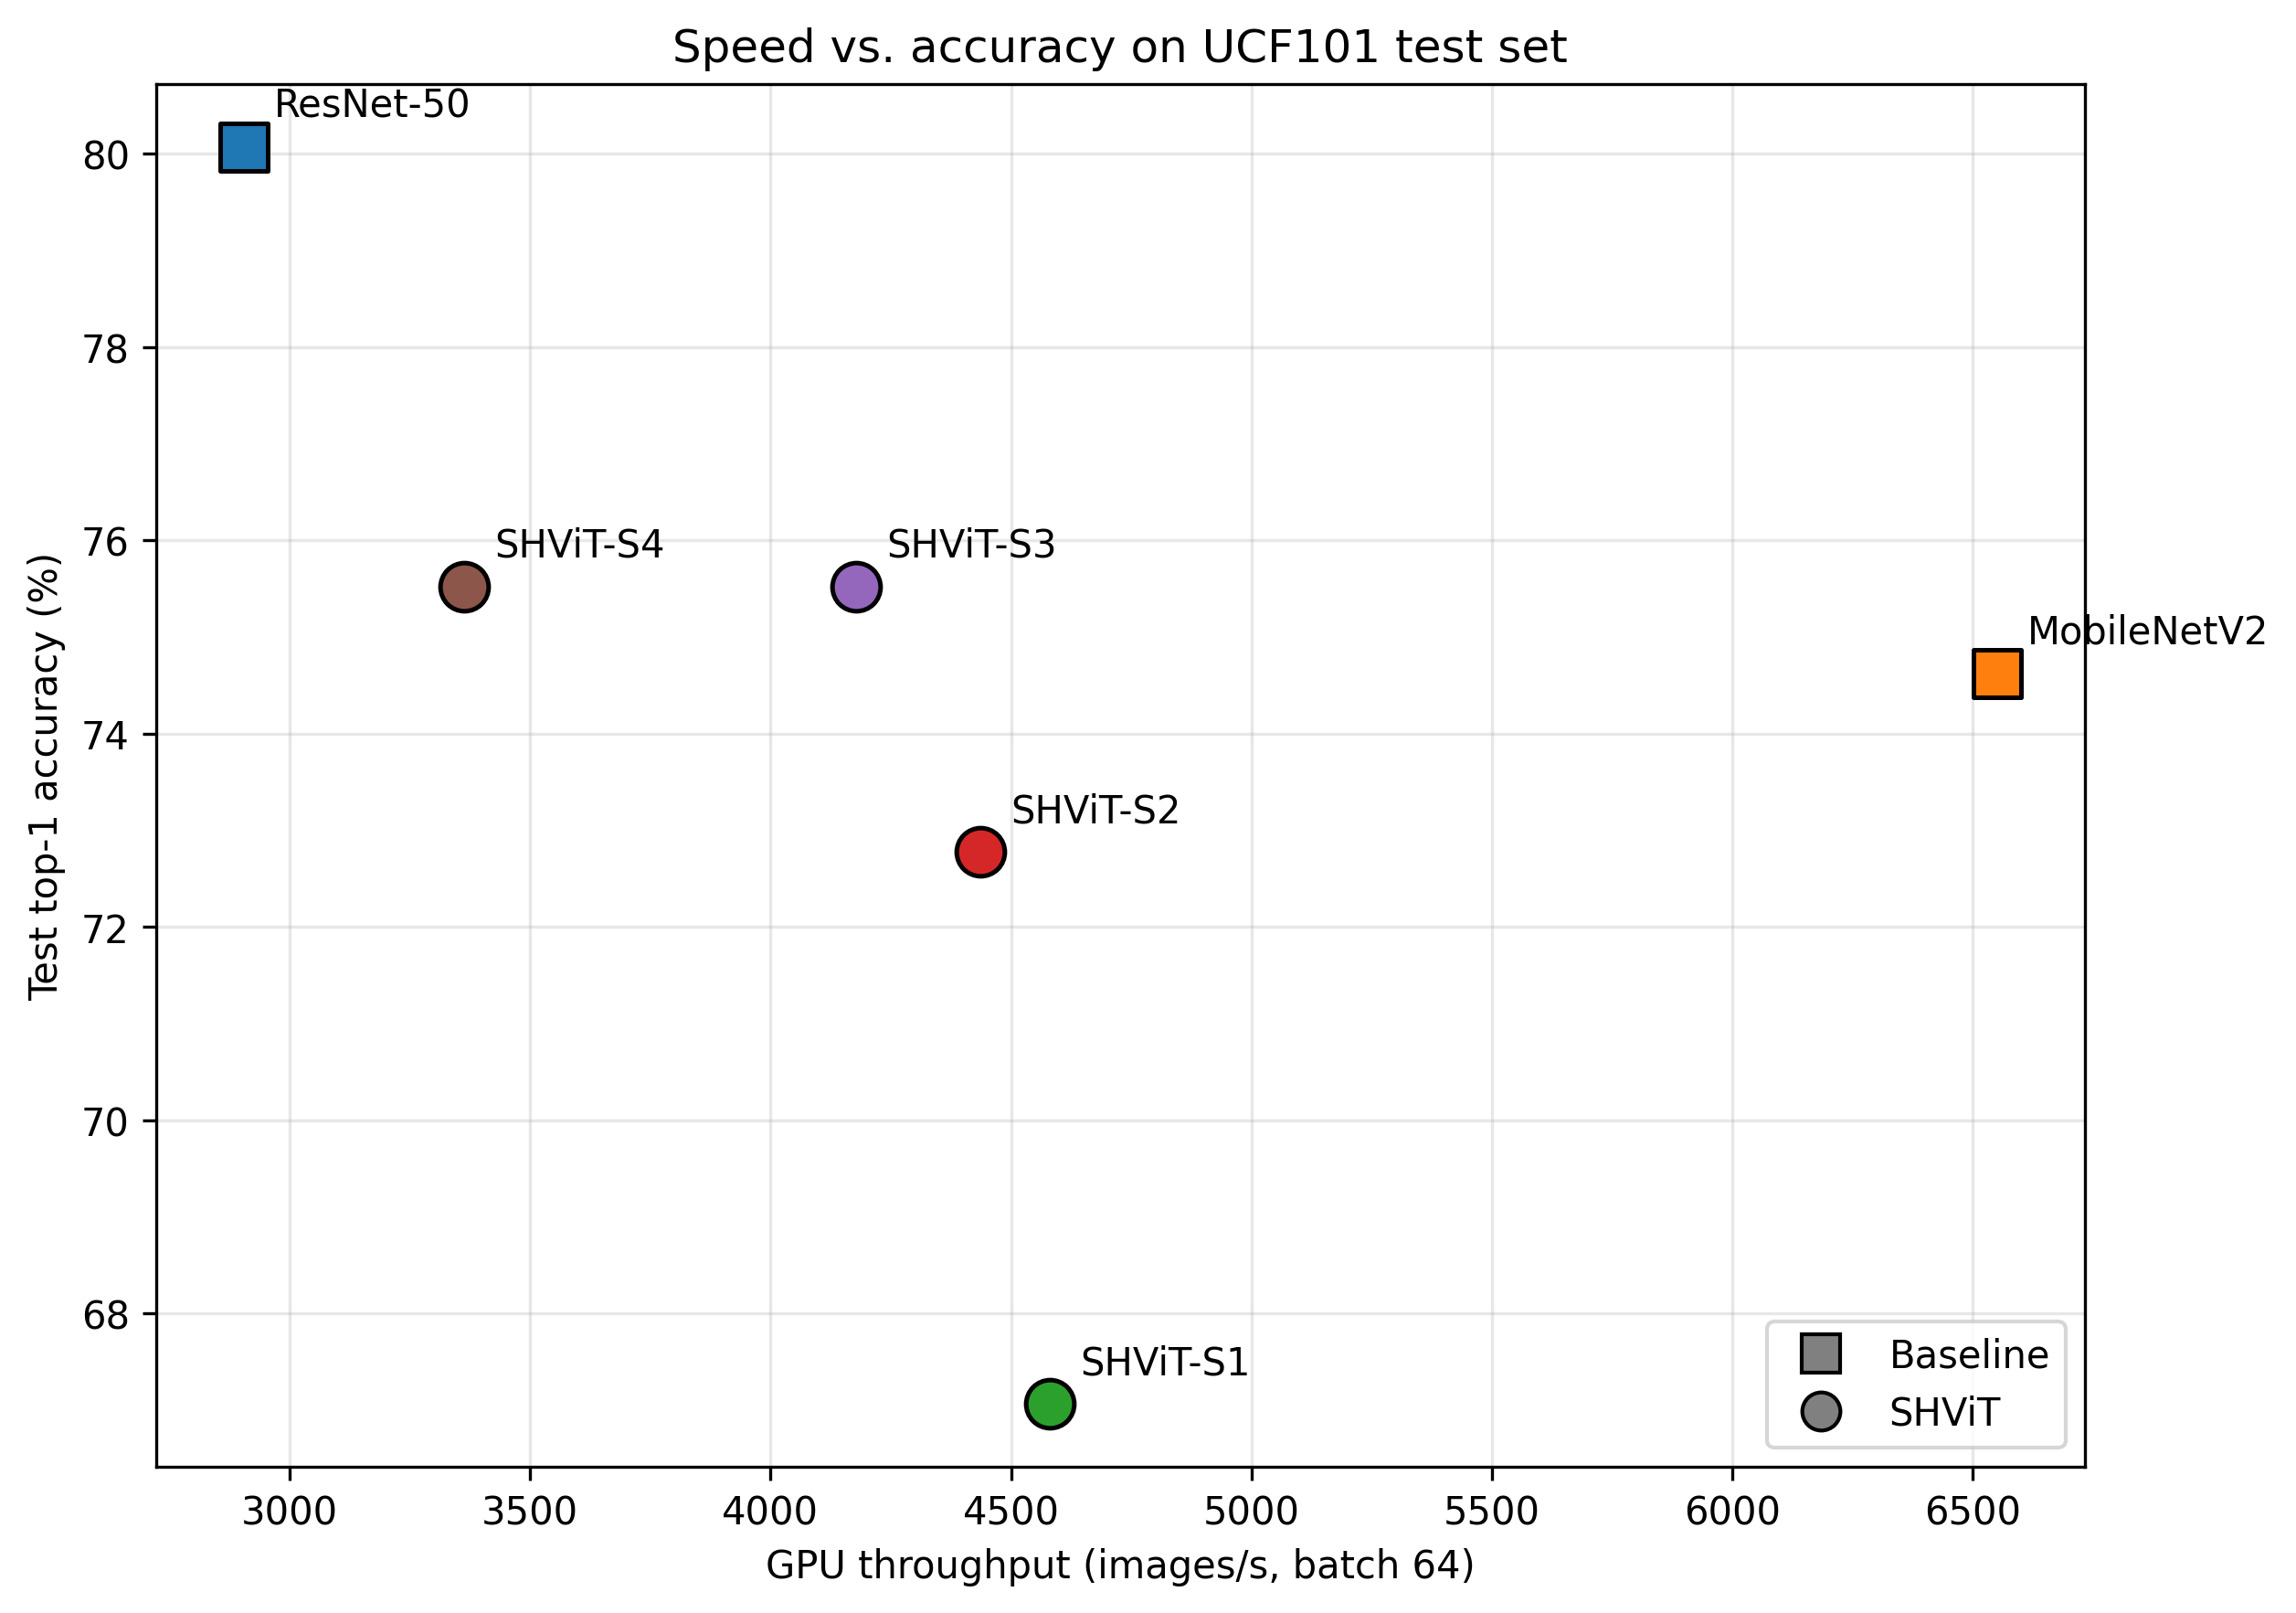

fig_training_curves.png


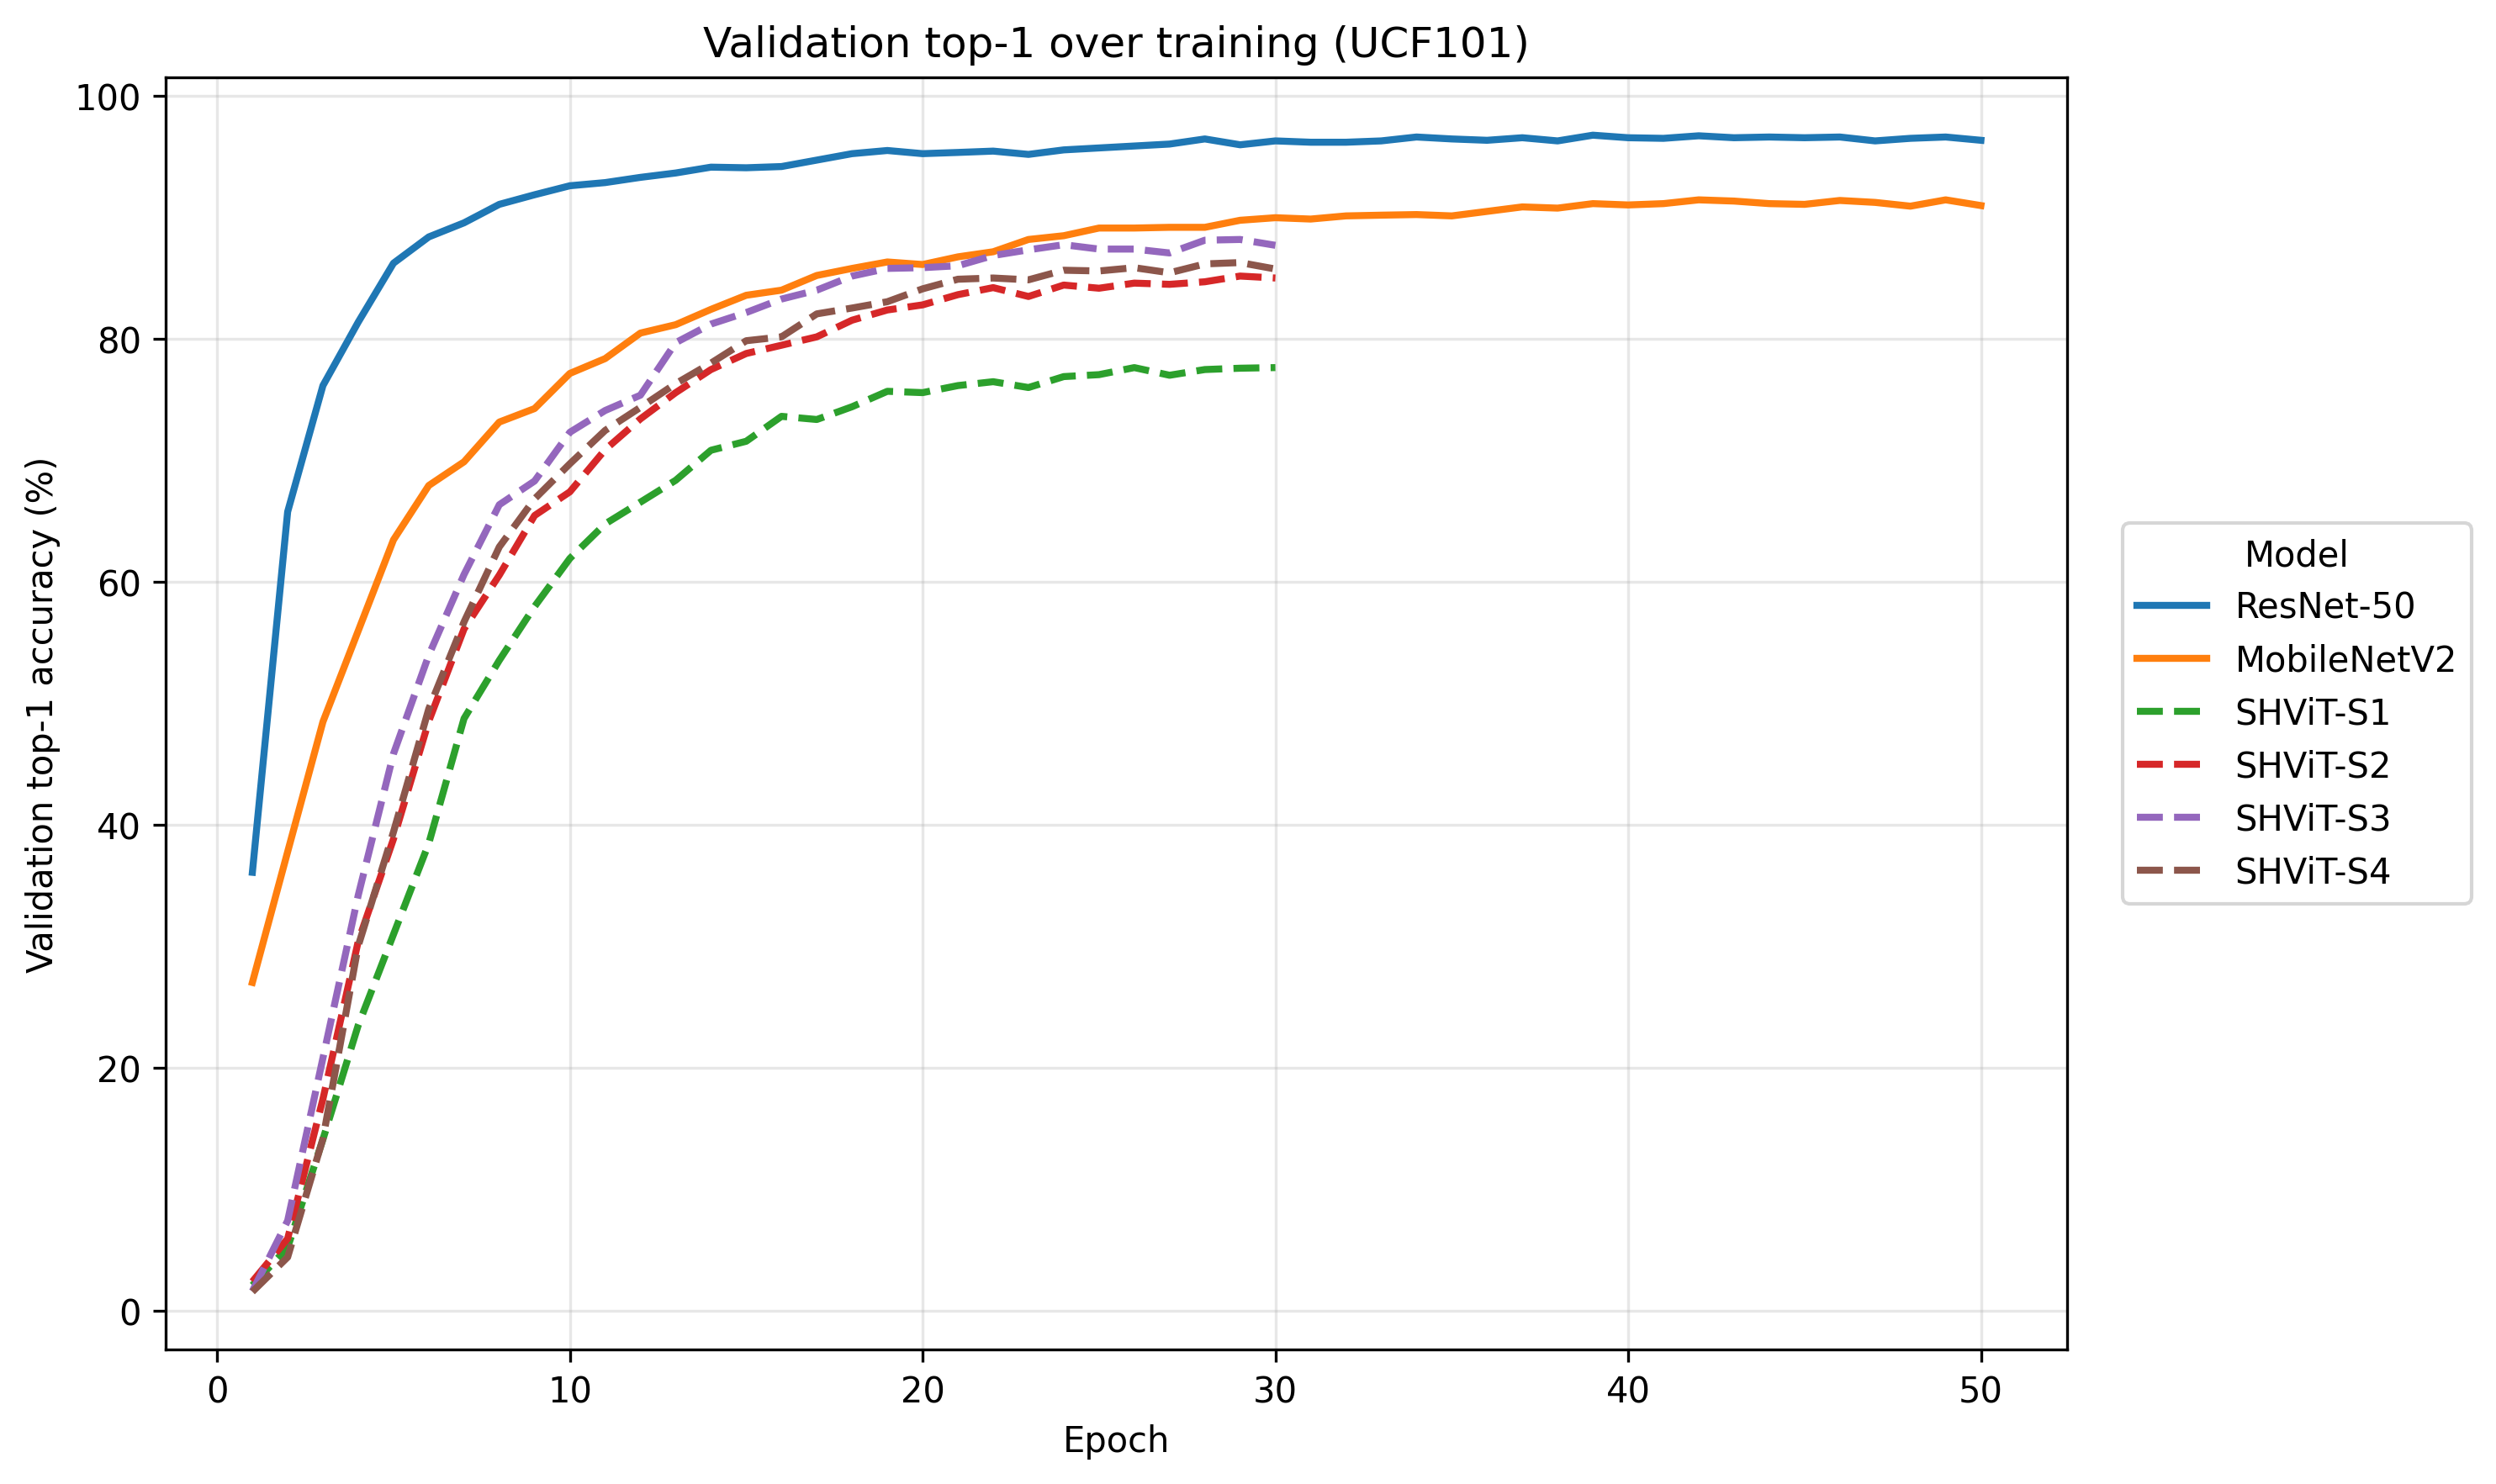

fig_accuracy_bars.png


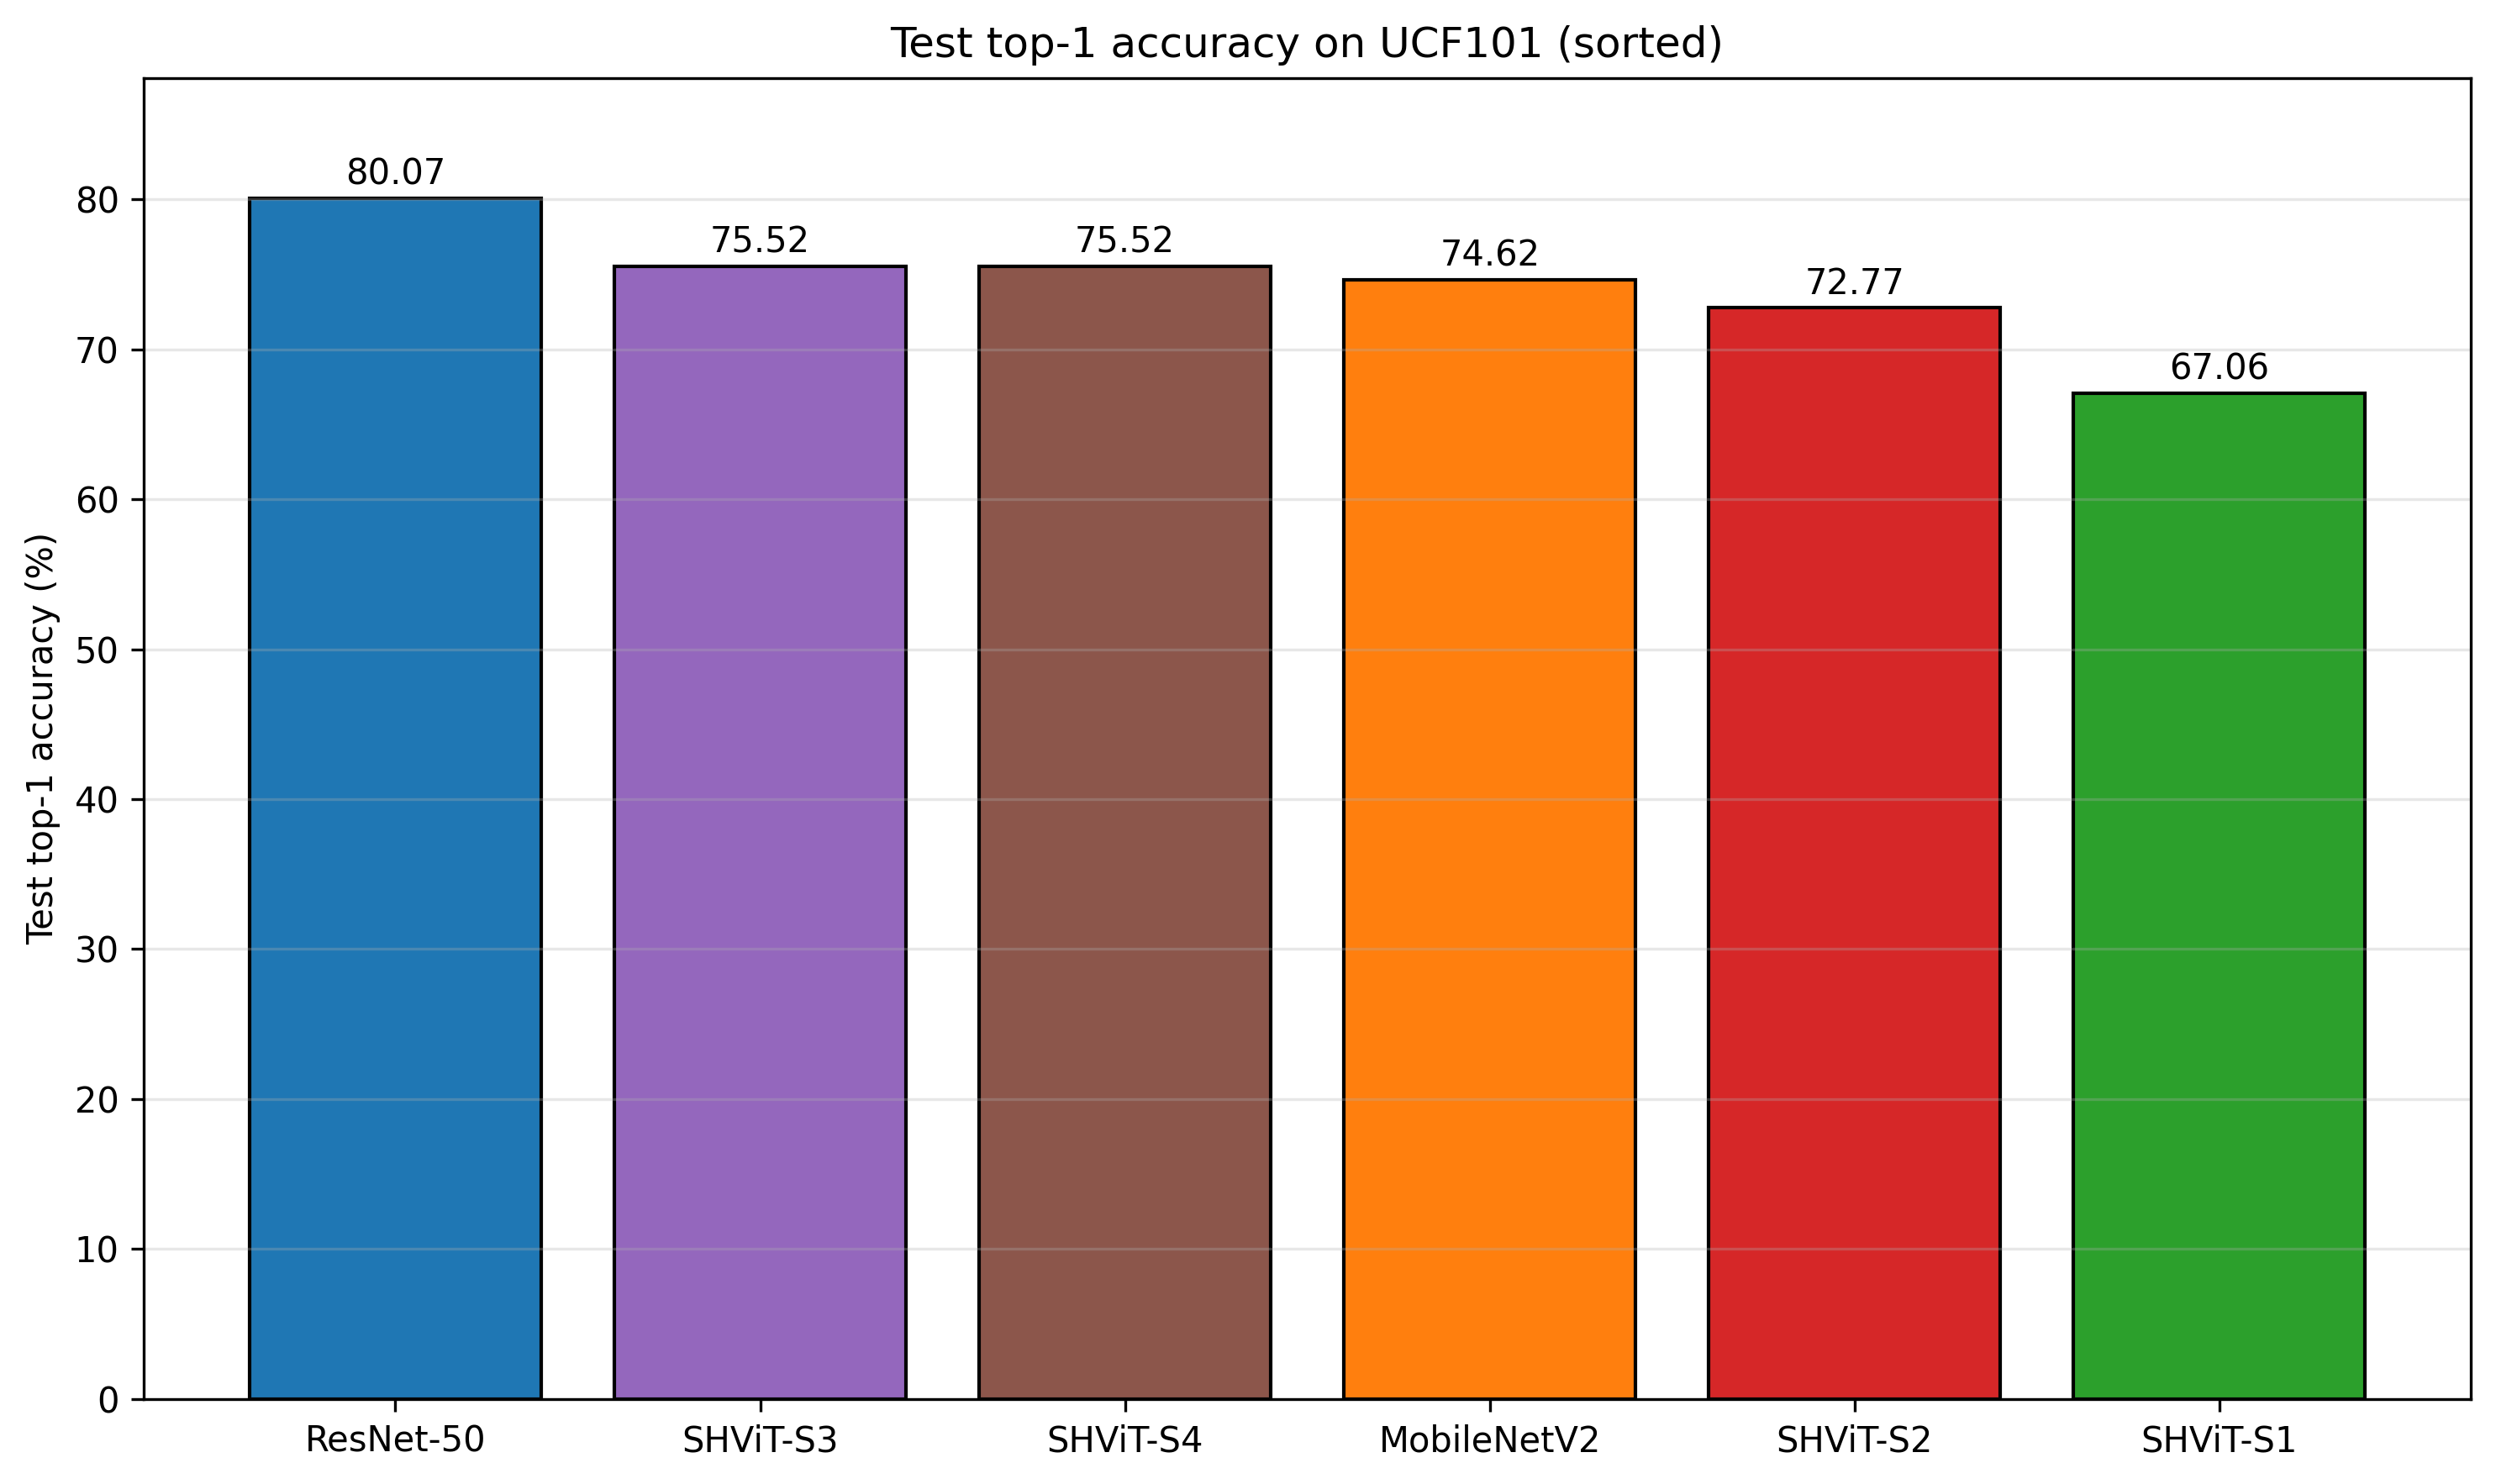

fig_train_loss.png


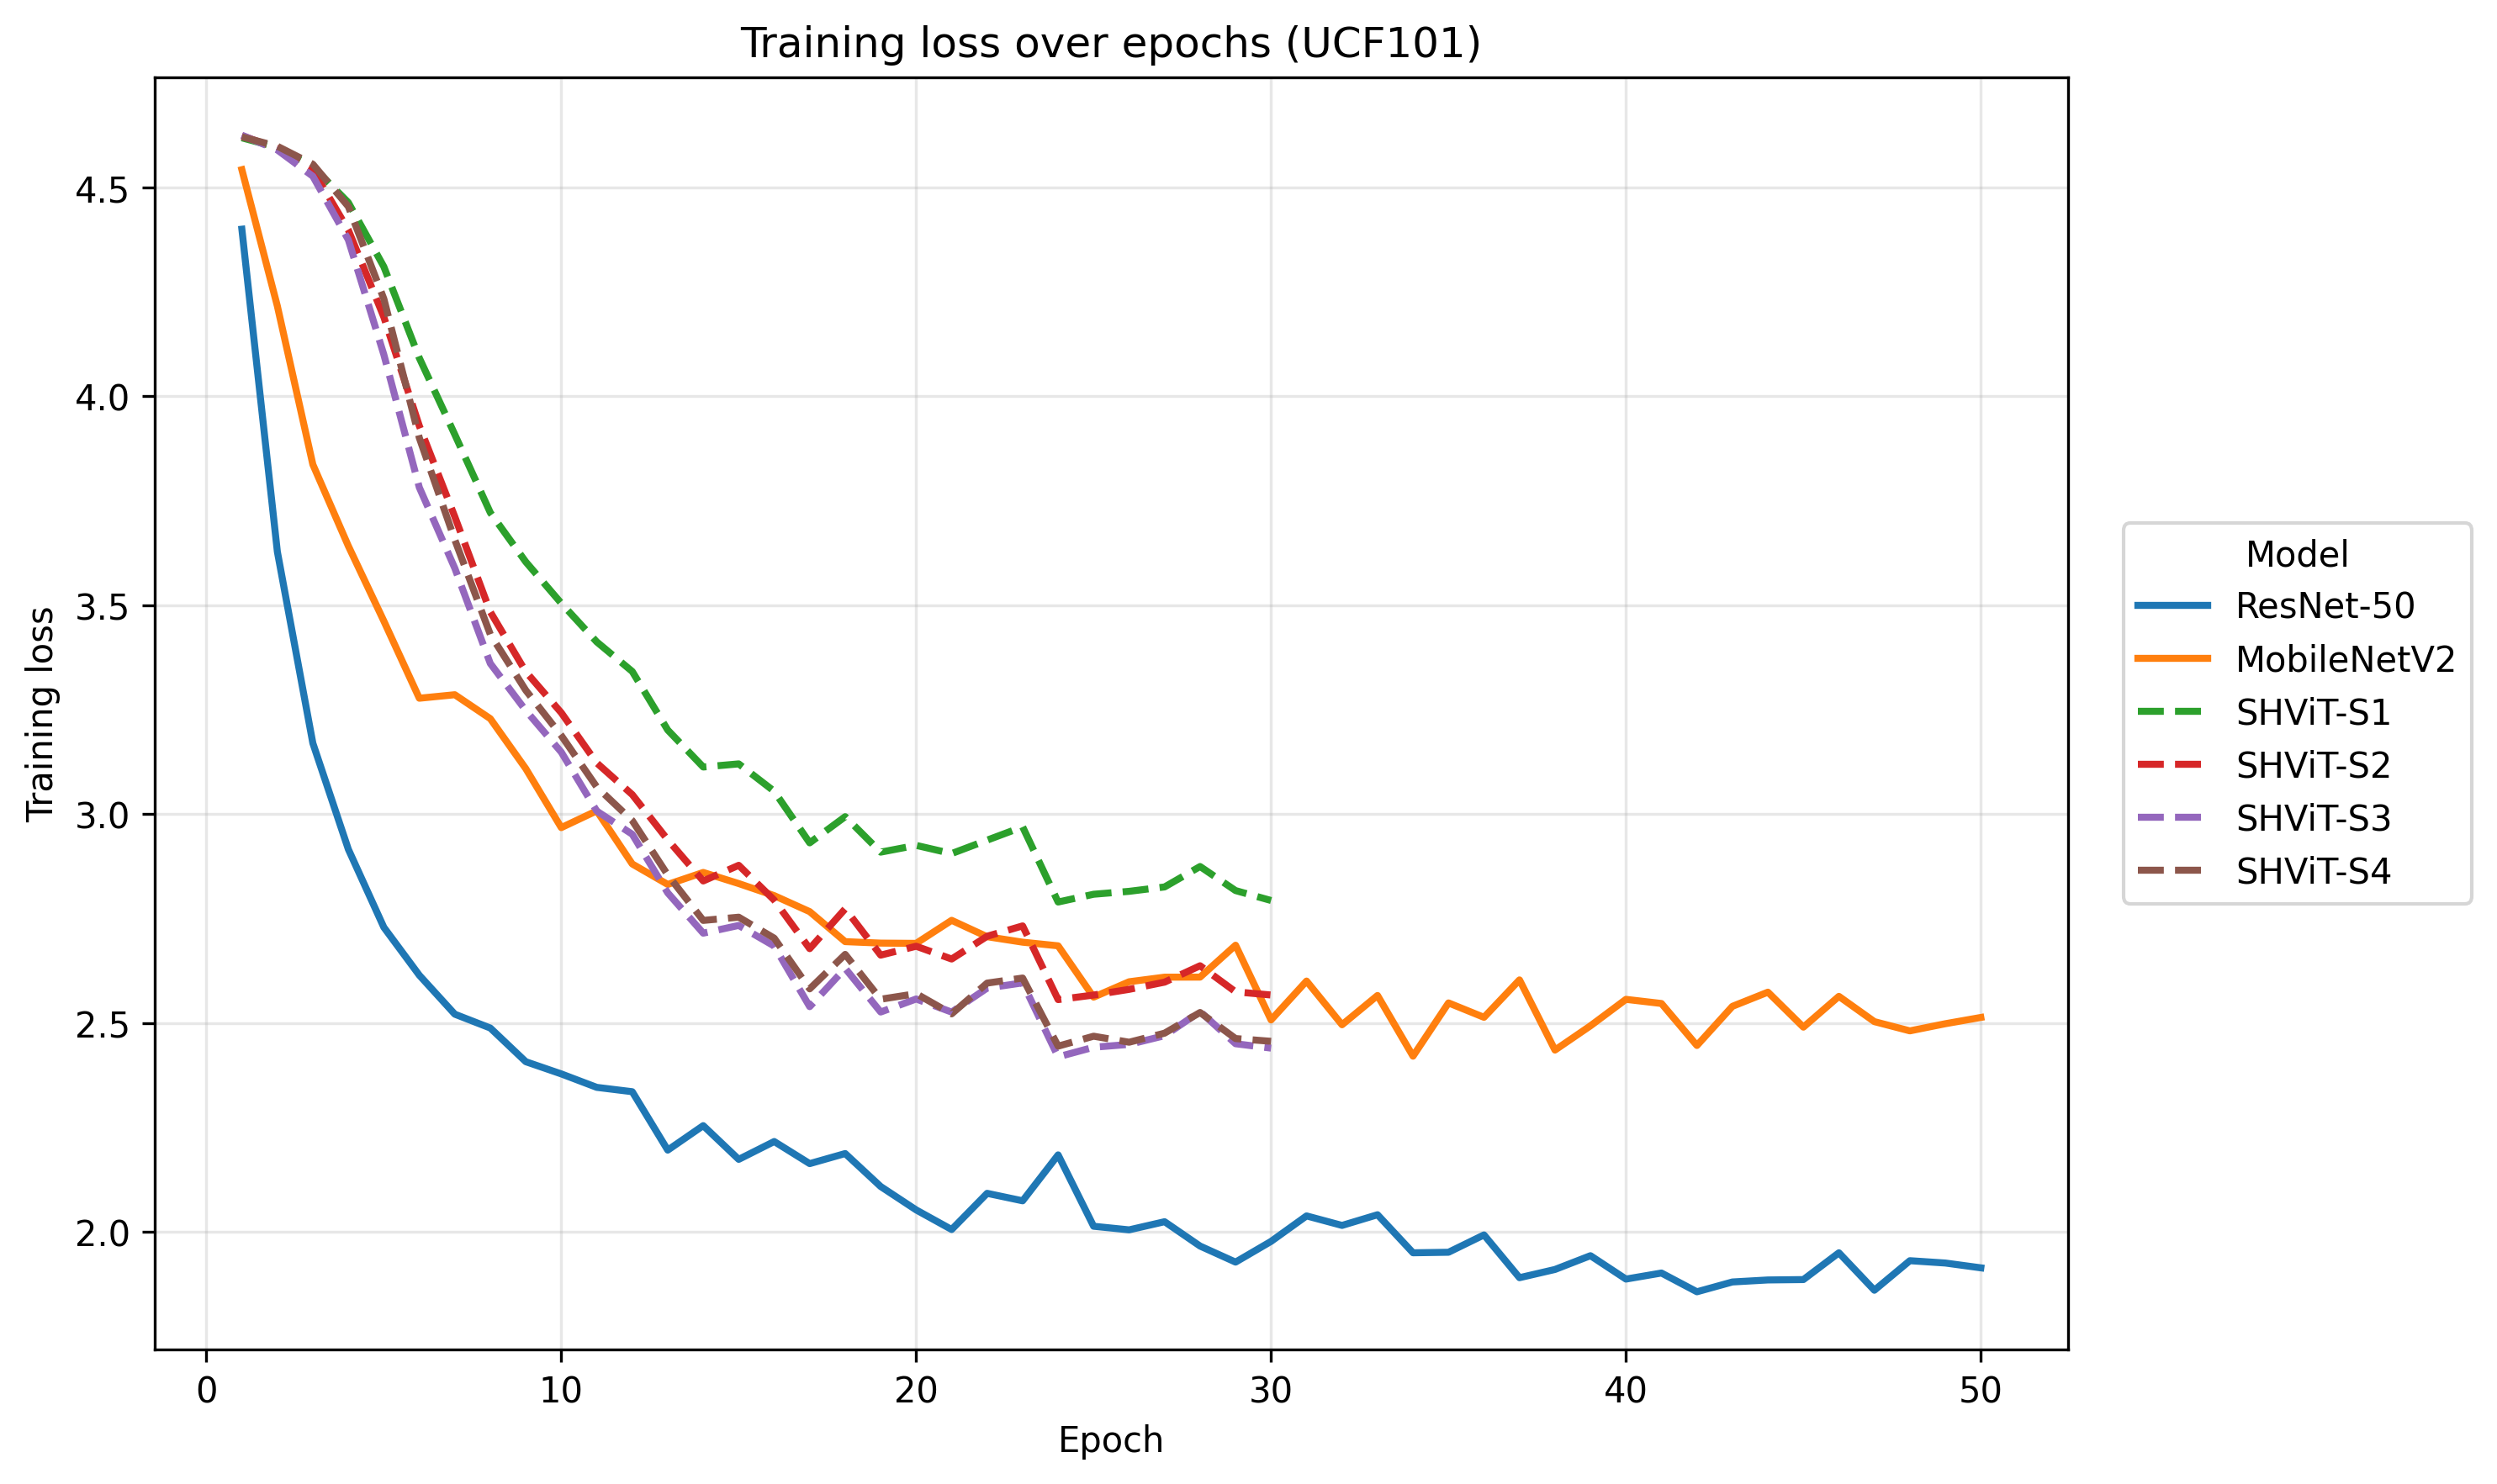

In [11]:
# Inline preview
from IPython.display import Image, display
for f in ['fig_speed_vs_accuracy.png', 'fig_training_curves.png',
          'fig_accuracy_bars.png', 'fig_train_loss.png']:
    p = f'{LOCAL_FIGURES}/{f}'
    if os.path.exists(p):
        print(f)
        display(Image(p, width=700))

## 8. Error analysis on SHViT-S4

Worst-15 categories, top-10 confused class pairs, confusion heatmap, misclassified image grid.

In [12]:
S4_CKPT = f'{STAGE3_LOCAL}/shvit_s4/best.pth'

!python /content/error_analysis.py \
    --results-dir "{LOCAL_RESULTS}" \
    --data-root   {LOCAL_DATA} \
    --shvit-dir   {SHVIT_DIR} \
    --checkpoint  "{S4_CKPT}" \
    --output-dir  "{LOCAL_ERROR}"

print('\nError analysis outputs:')
for f in sorted(os.listdir(LOCAL_ERROR)):
    sz = os.path.getsize(f'{LOCAL_ERROR}/{f}') / 1024
    print(f'  {f}  ({sz:.0f} KB)')


[ucf101] mid-frame images already present: /content/ucf101_local/ucf101/UCF-101-midframes
[ucf101] split already present: /content/ucf101_local/ucf101/split_zhou_UCF101.json
Reading split from /content/ucf101_local/ucf101/split_zhou_UCF101.json

Worst-101 classes:
  Handstand_Walking              0.00%
  Pizza_Tossing                 12.12%
  Lunges                        13.51%
  High_Jump                     18.92%
  Nunchucks                     20.00%
  Body_Weight_Squats            30.00%
  Pull_Ups                      39.29%
  Javelin_Throw                 41.94%
  Wall_Pushups                  42.86%
  Basketball                    42.86%

Best-101 classes:
  Writing_On_Board             100.00%
  Rowing                       100.00%
  Playing_Tabla                100.00%
  Playing_Dhol                 100.00%
  Playing_Guitar               100.00%
  Cutting_In_Kitchen           100.00%
  Baby_Crawling                100.00%
  Billiards                    100.00%
  Basketball_D

confusion_top20.png


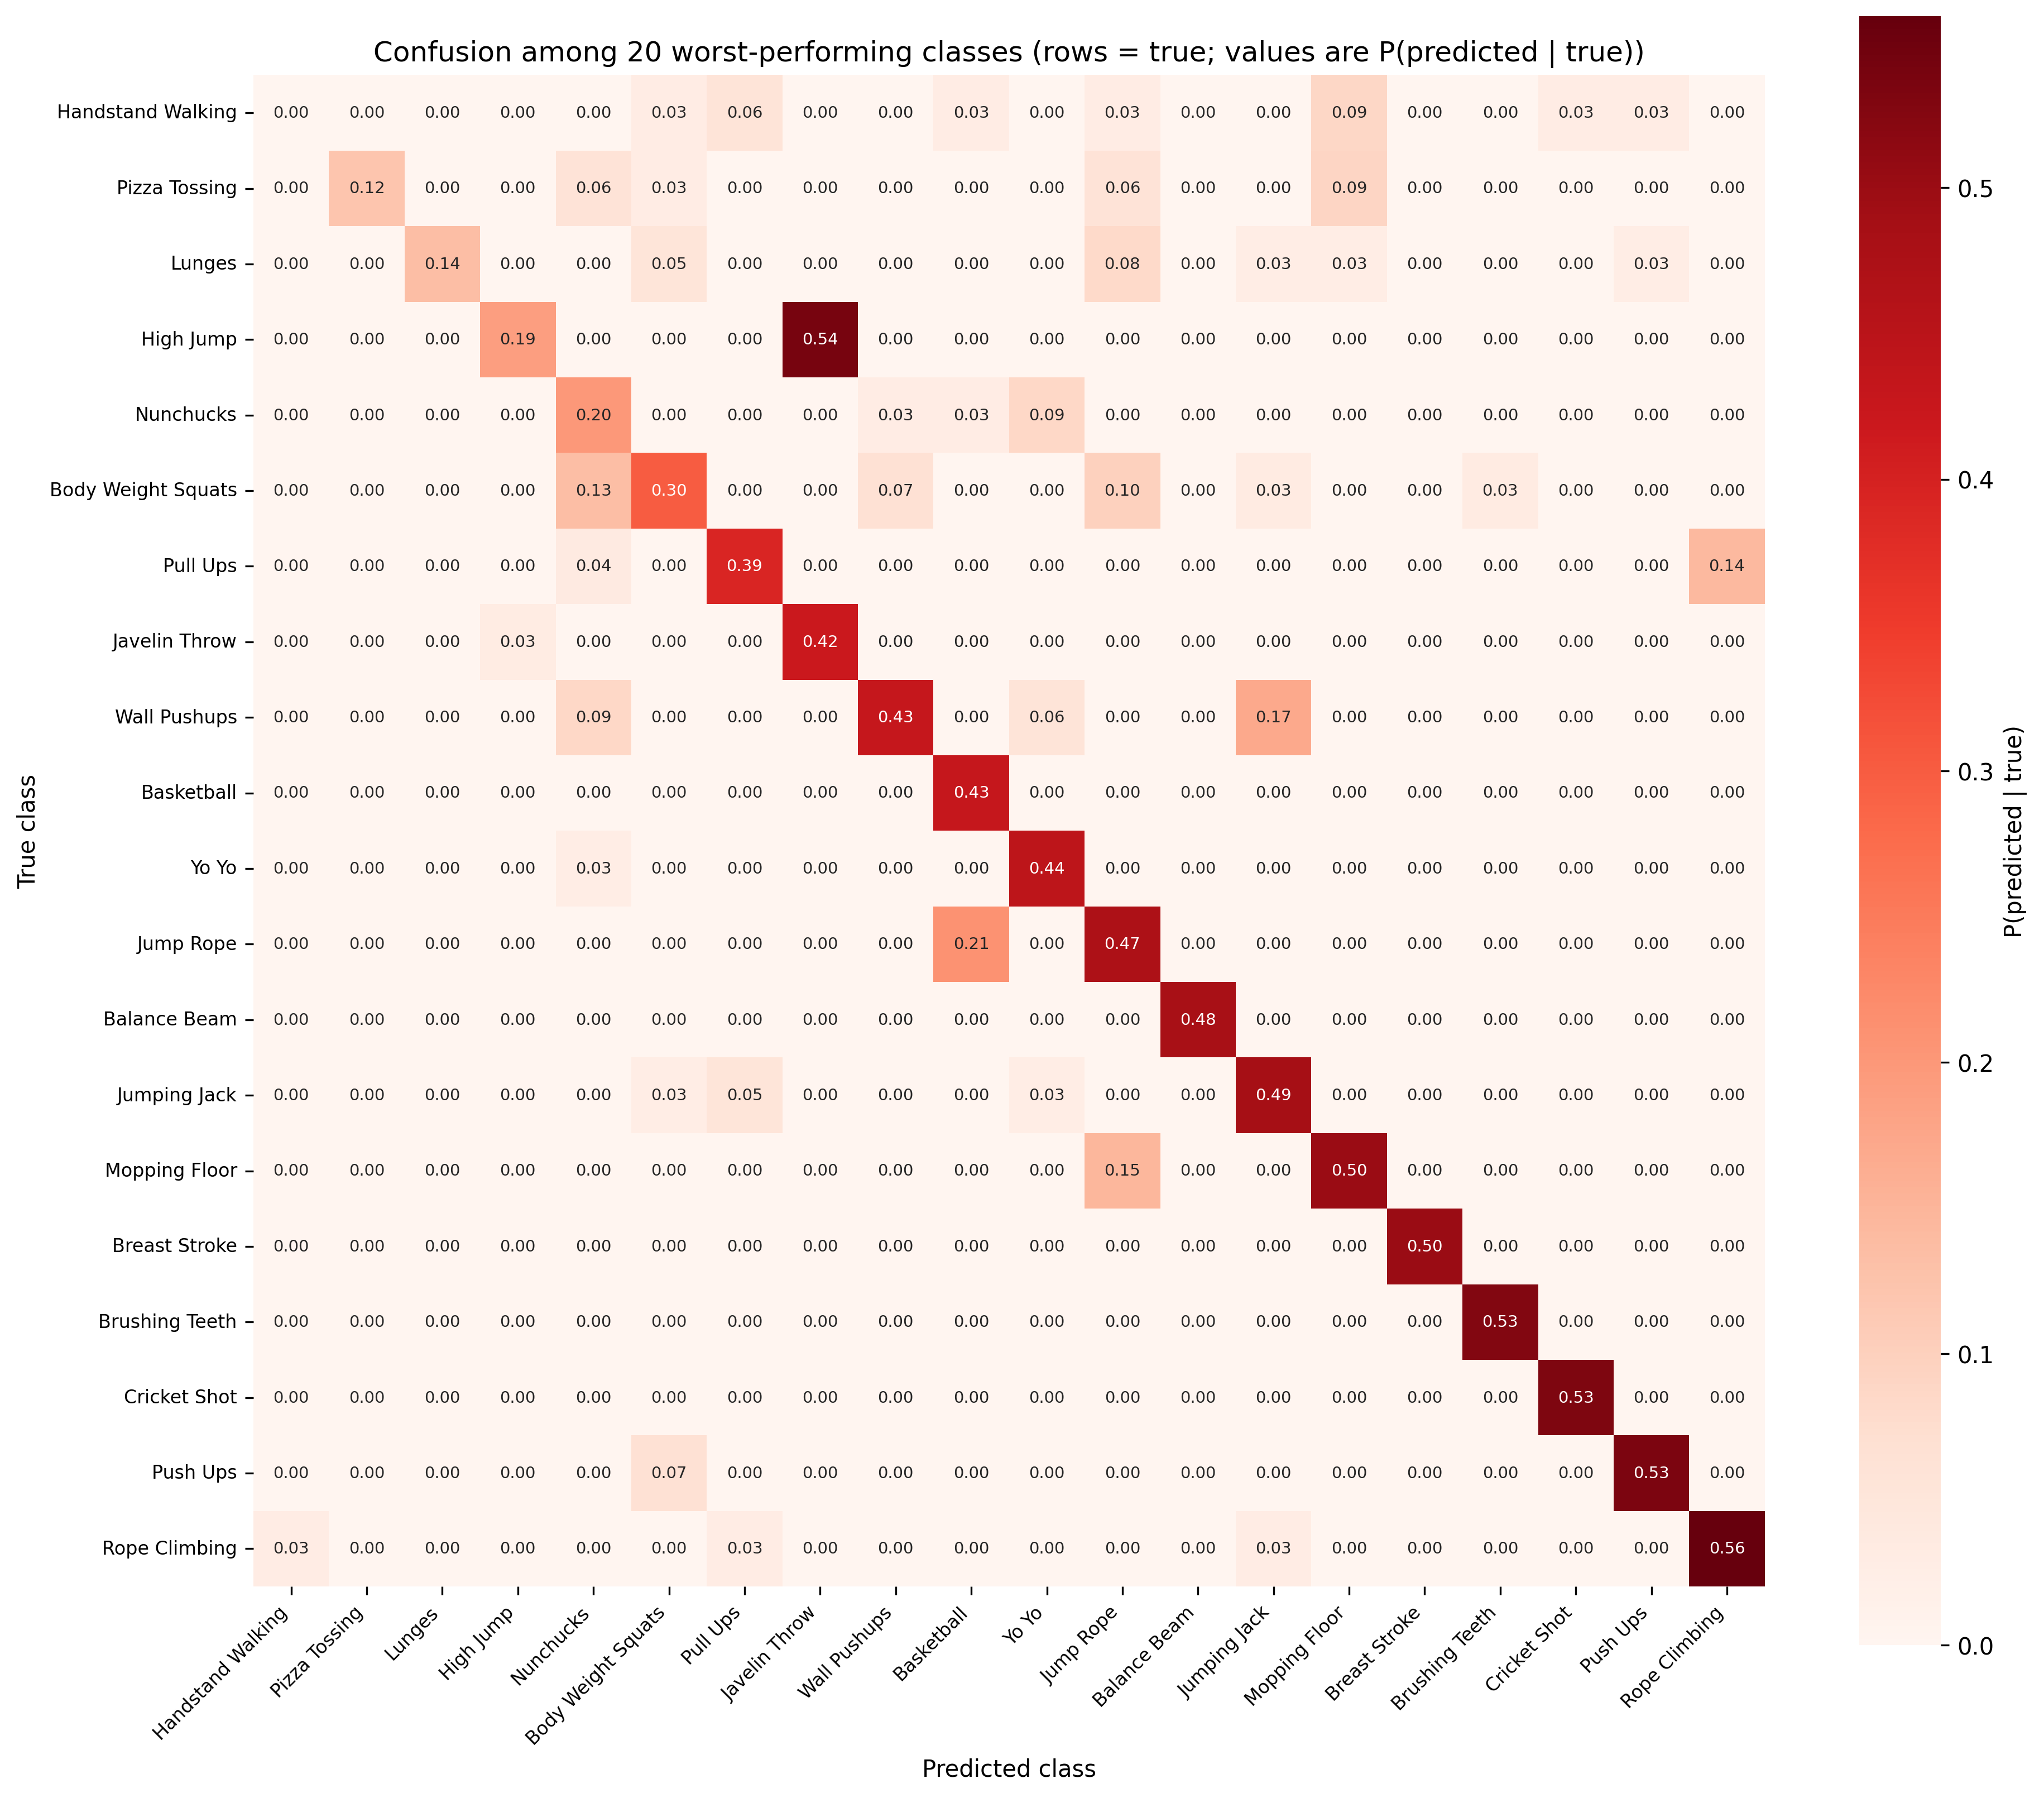

misclassified_grid.png


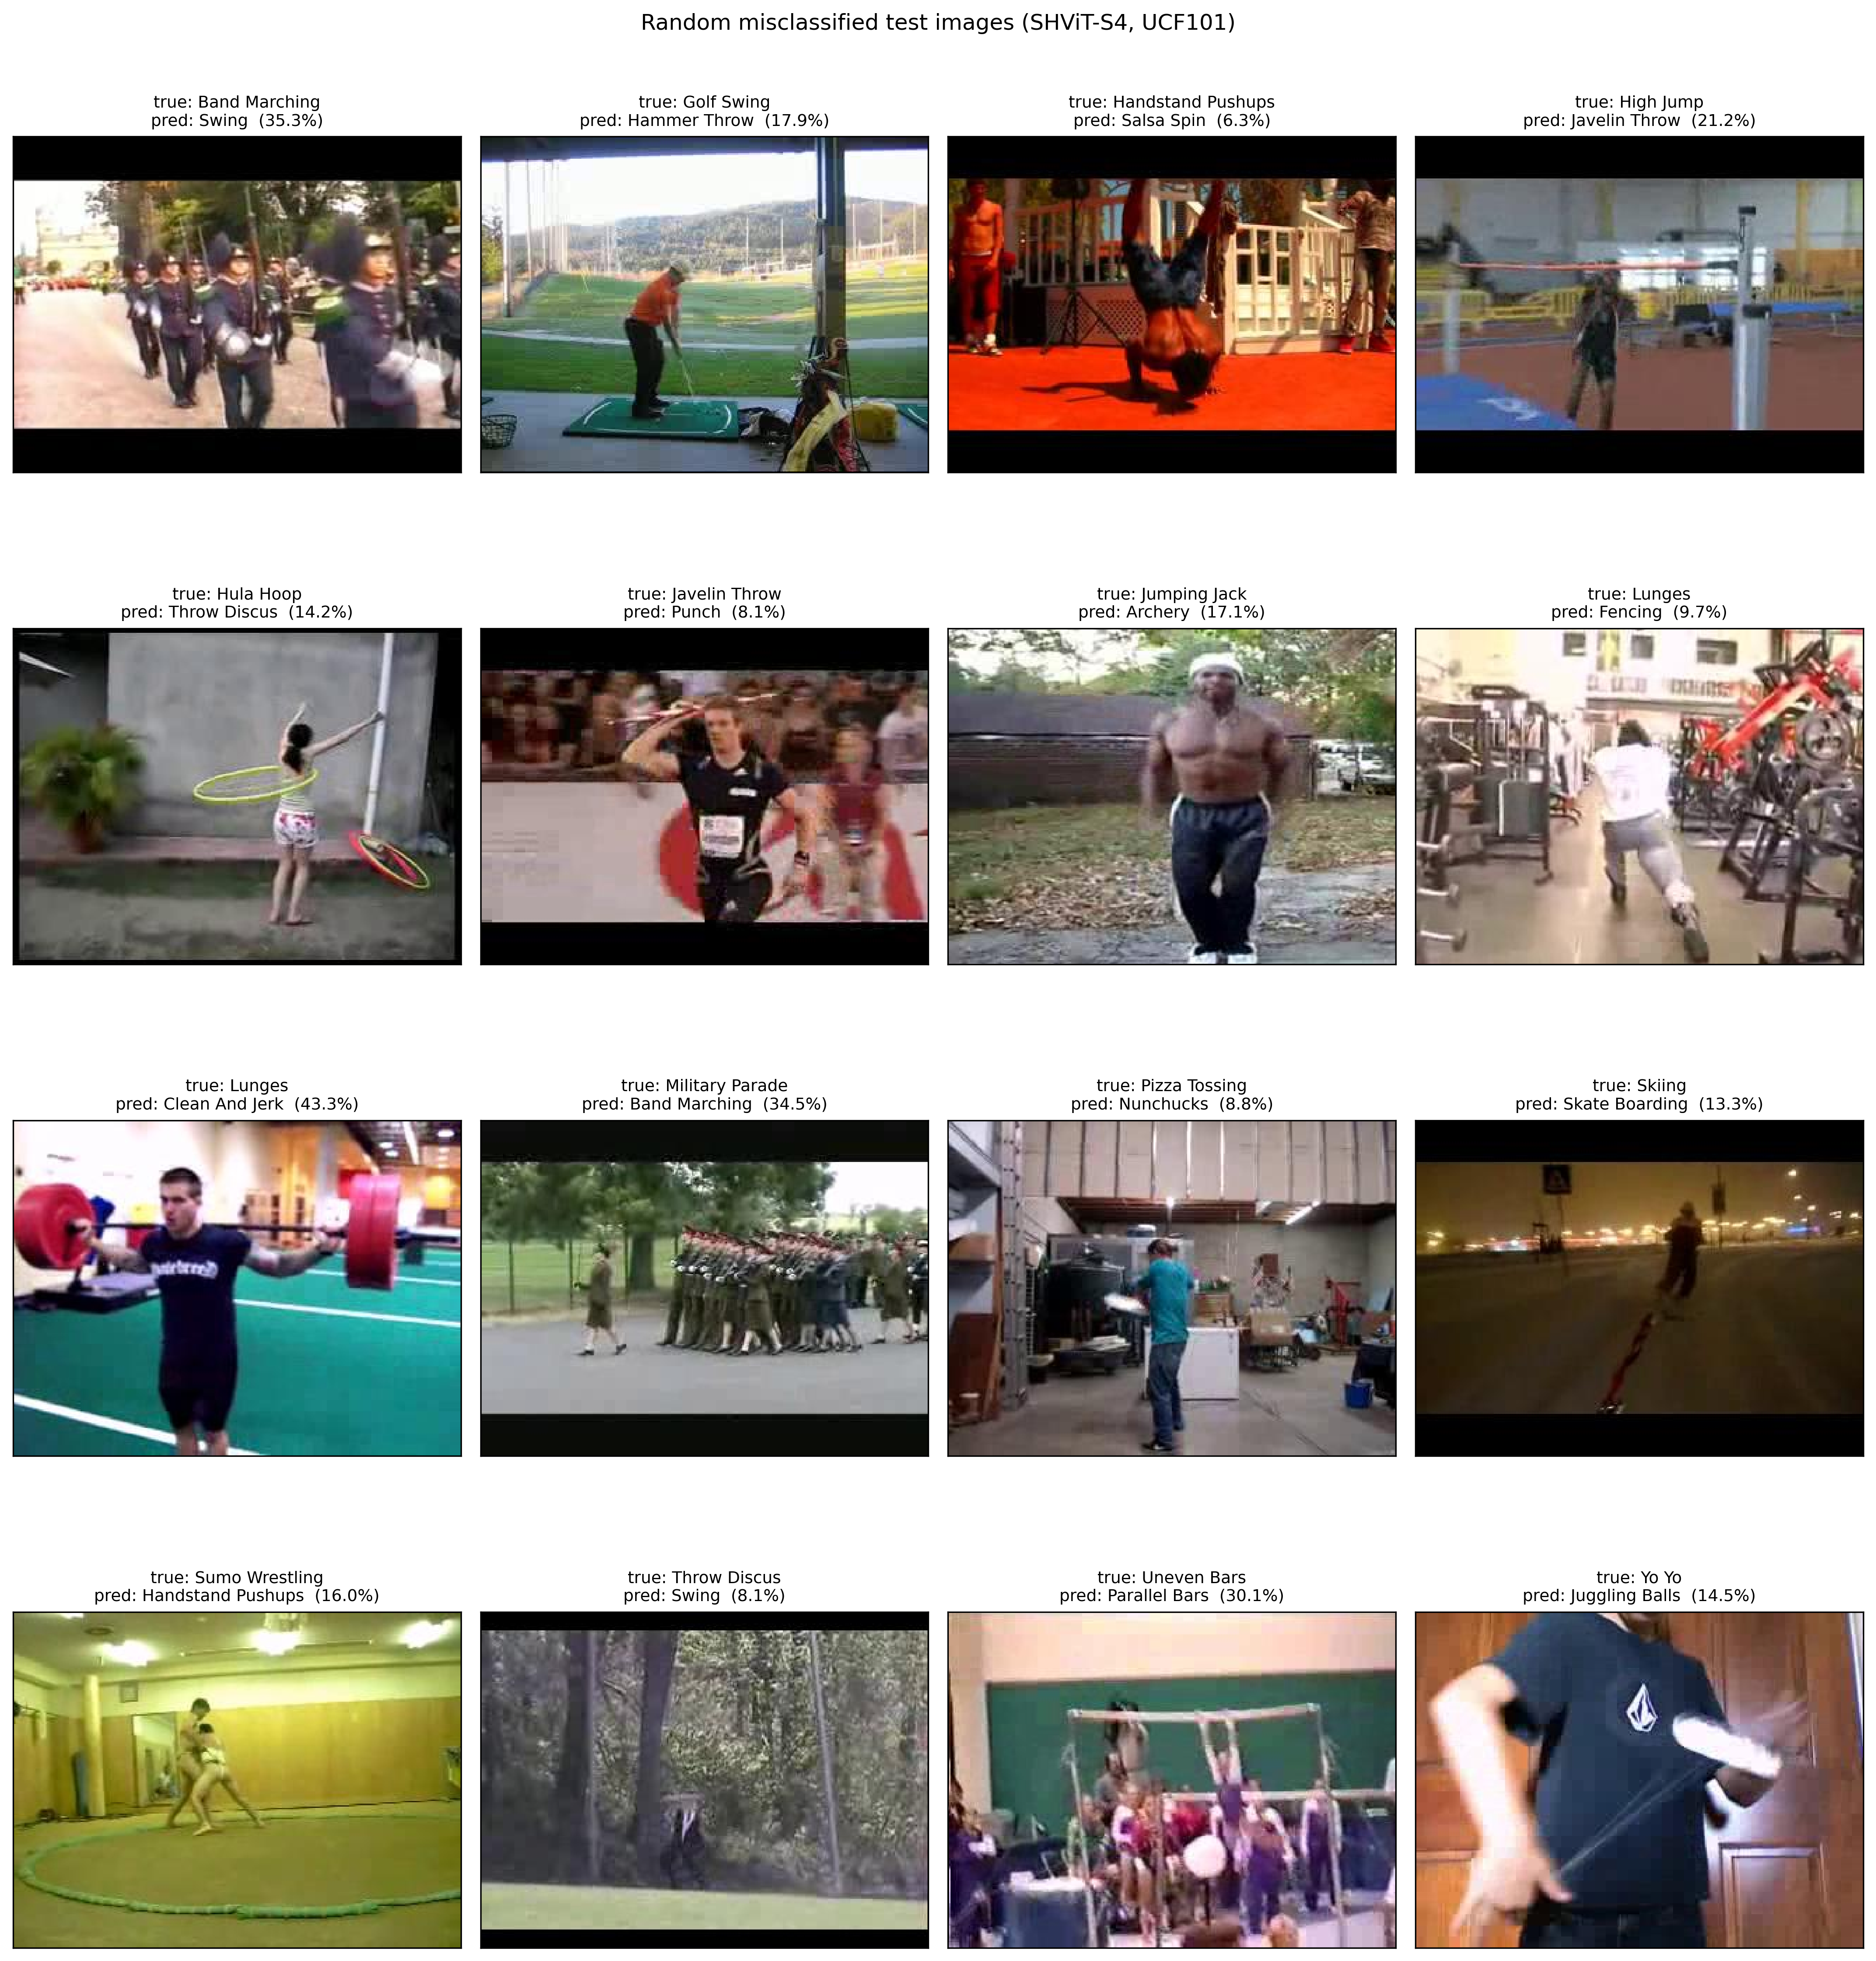

worst_15_categories.png


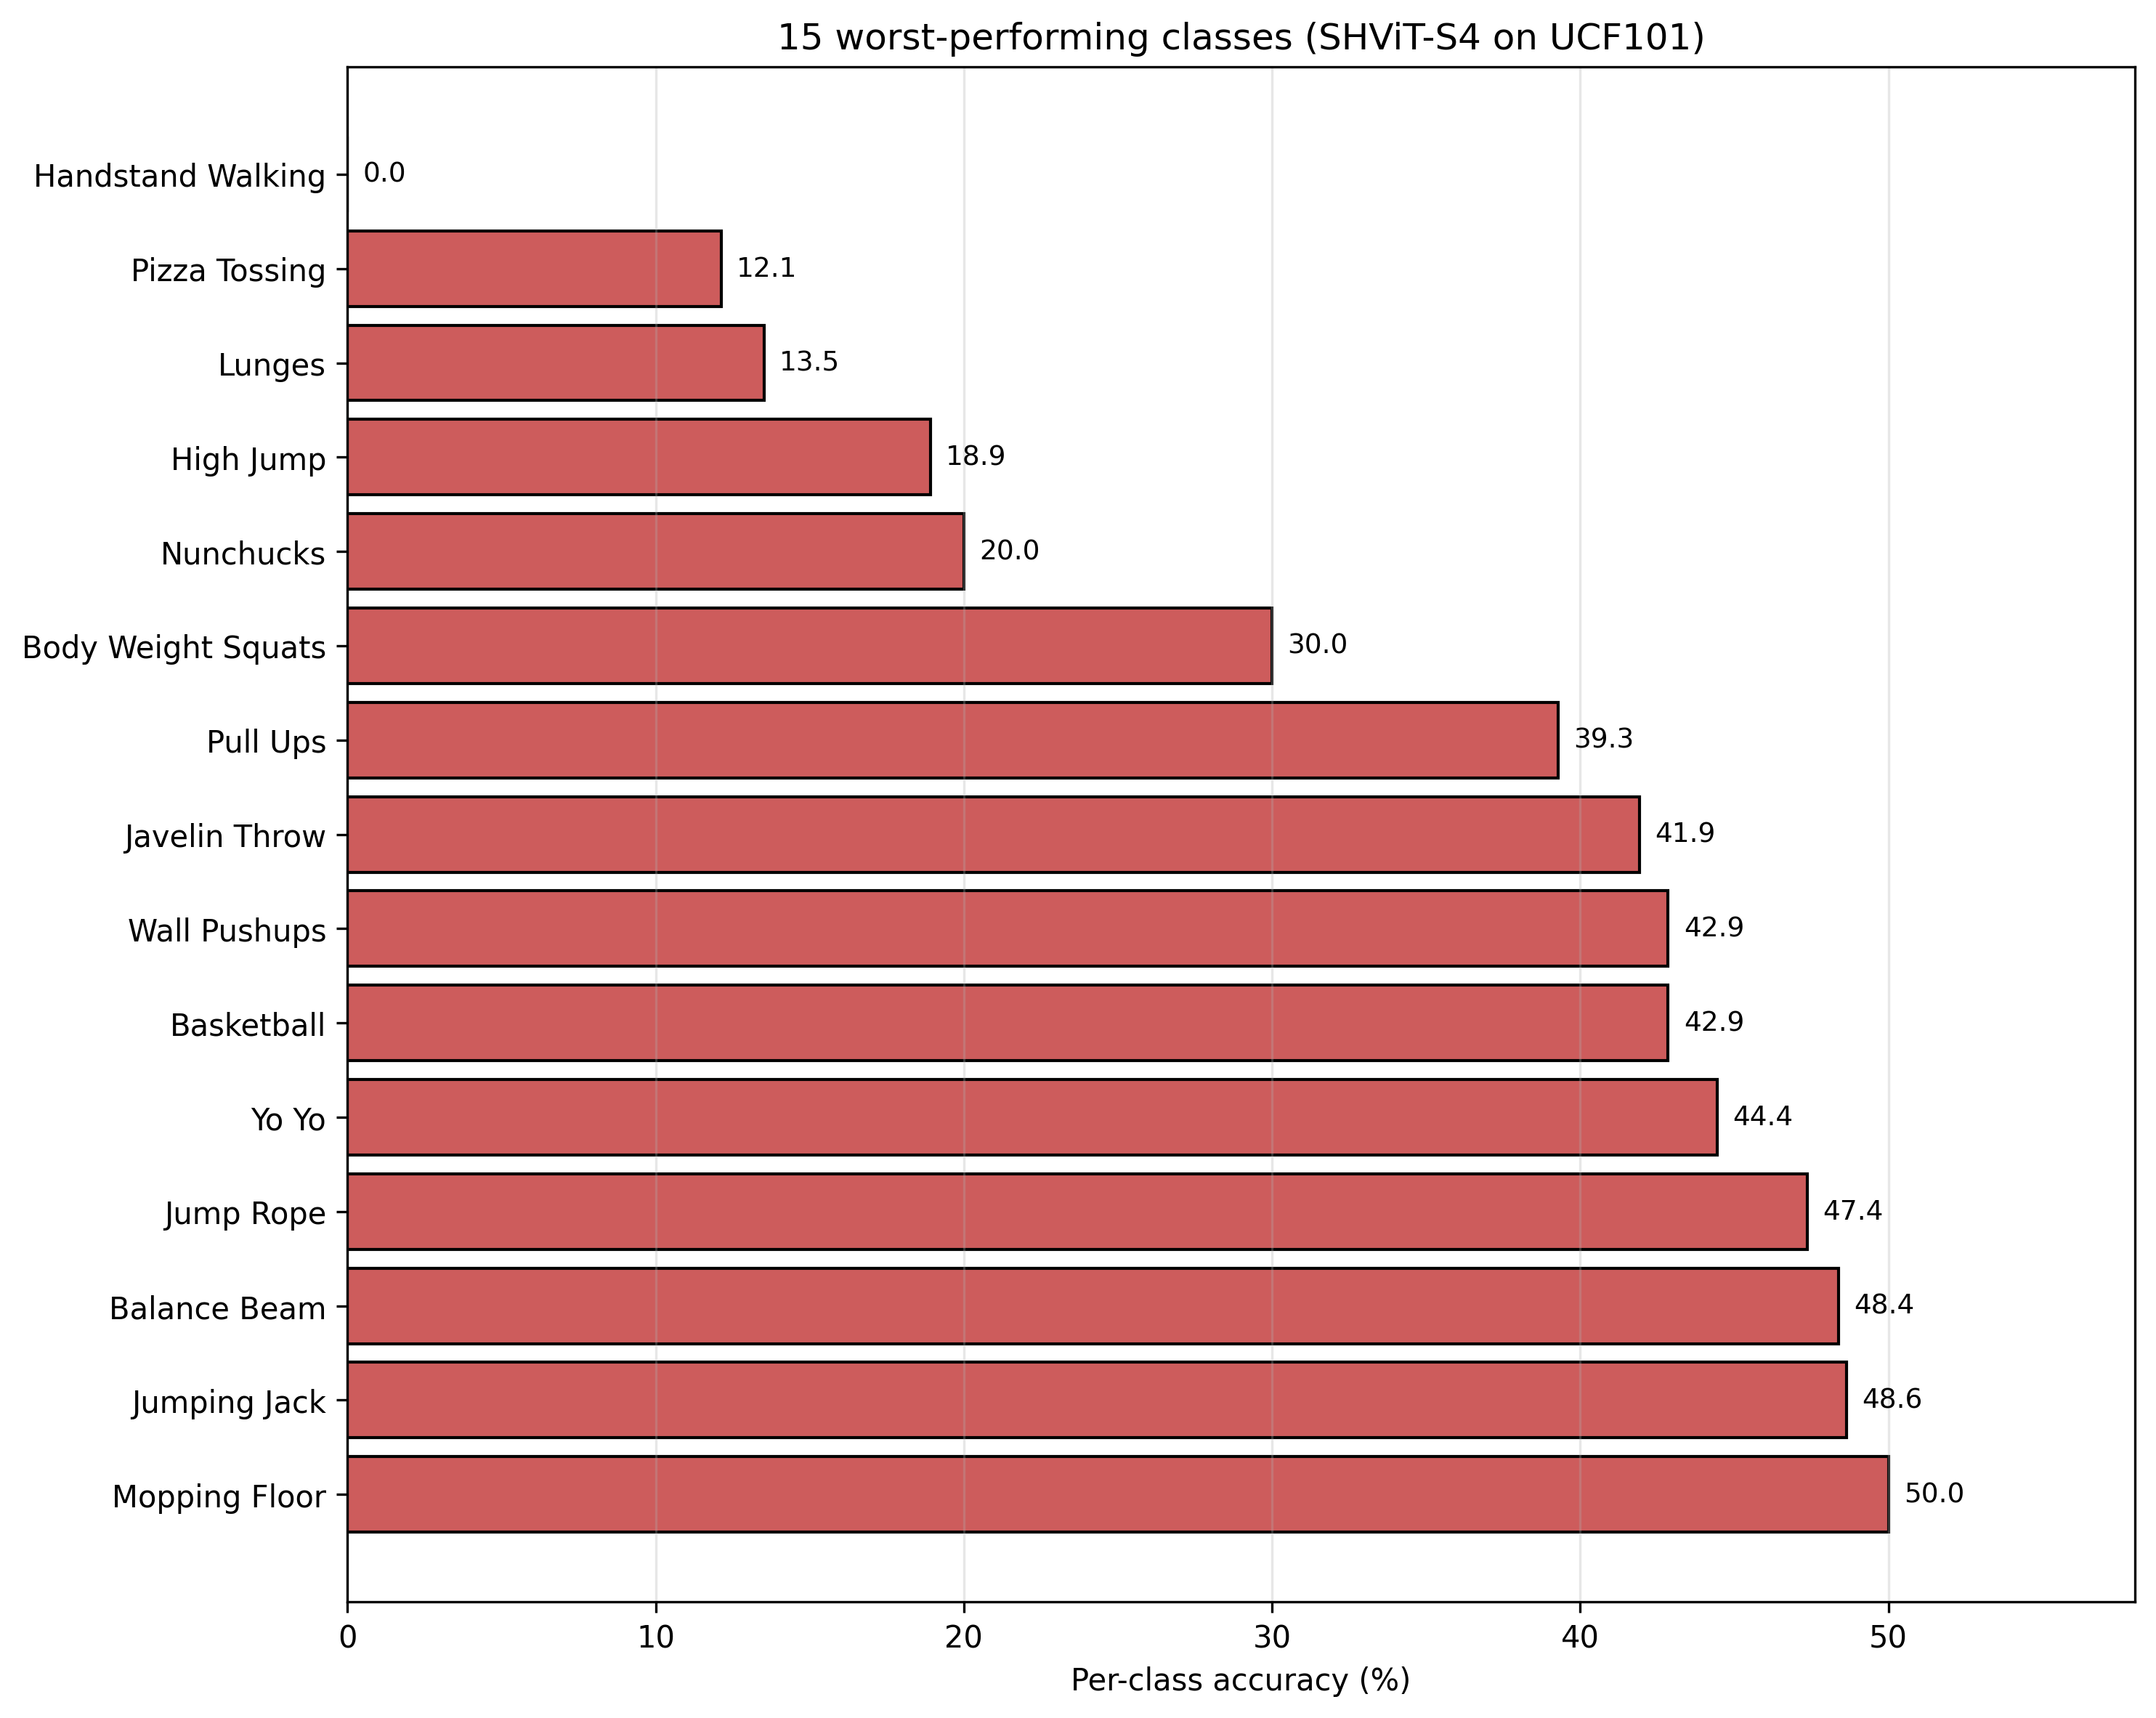

SHViT-S4 Error Analysis Summary (UCF101)

Overall:
  - Test set size       : 3,783 images
  - Test top-1 accuracy : 75.52%
  - Test top-5 accuracy : 94.21%

Worst-101 classes by per-class accuracy:
   1. Handstand_Walking              0.00%
   2. Pizza_Tossing                 12.12%
   3. Lunges                        13.51%
   4. High_Jump                     18.92%
   5. Nunchucks                     20.00%
   6. Body_Weight_Squats            30.00%
   7. Pull_Ups                      39.29%
   8. Javelin_Throw                 41.94%
   9. Wall_Pushups                  42.86%
  10. Basketball                    42.86%

Best-101 classes (for context):
   1. Writing_On_Board             100.00%
   2. Rowing                       100.00%
   3. Playing_Tabla                100.00%
   4. Playing_Dhol                 100.00%
   5. Playing_Guitar               100.00%
   6. Cutting_In_Kitchen           100.00%
   7. Baby_Crawling                100.00%
   8. Billiards                    100

In [13]:
# Inline preview of error figures + summary text
for f in ['confusion_top20.png', 'misclassified_grid.png', 'worst_15_categories.png']:
    p = f'{LOCAL_ERROR}/{f}'
    if os.path.exists(p):
        print(f)
        display(Image(p, width=700))

summary = f'{LOCAL_ERROR}/error_analysis_summary.txt'
if os.path.exists(summary):
    with open(summary) as f:
        print(f.read())

## 9. Demo on a single image

Smoke test for `demo.py`. By default this grabs the first scene image
found under `ucf101/UCF-101-midframes/`; edit `DEMO_IMAGE` to try any other scene.


Using image: /content/ucf101_local/ucf101/UCF-101-midframes/Apply_Eye_Makeup/v_ApplyEyeMakeup_g01_c01.jpg
Device: cuda
[ucf101] mid-frame images already present: /content/ucf101_local/ucf101/UCF-101-midframes
[ucf101] split already present: /content/ucf101_local/ucf101/split_zhou_UCF101.json
Reading split from /content/ucf101_local/ucf101/split_zhou_UCF101.json

Top-5 predictions for v_ApplyEyeMakeup_g01_c01.jpg:
  1. Apply_Eye_Makeup              47.75%
  2. Haircut                        7.30%
  3. Shaving_Beard                  6.74%
  4. Head_Massage                   2.51%
  5. Apply_Lipstick                 2.30%

Saved /content/CV_Research_Paper_UCF101/Stage 4: Benchmarking and Demo/analysis/demo_output/demo_output.png


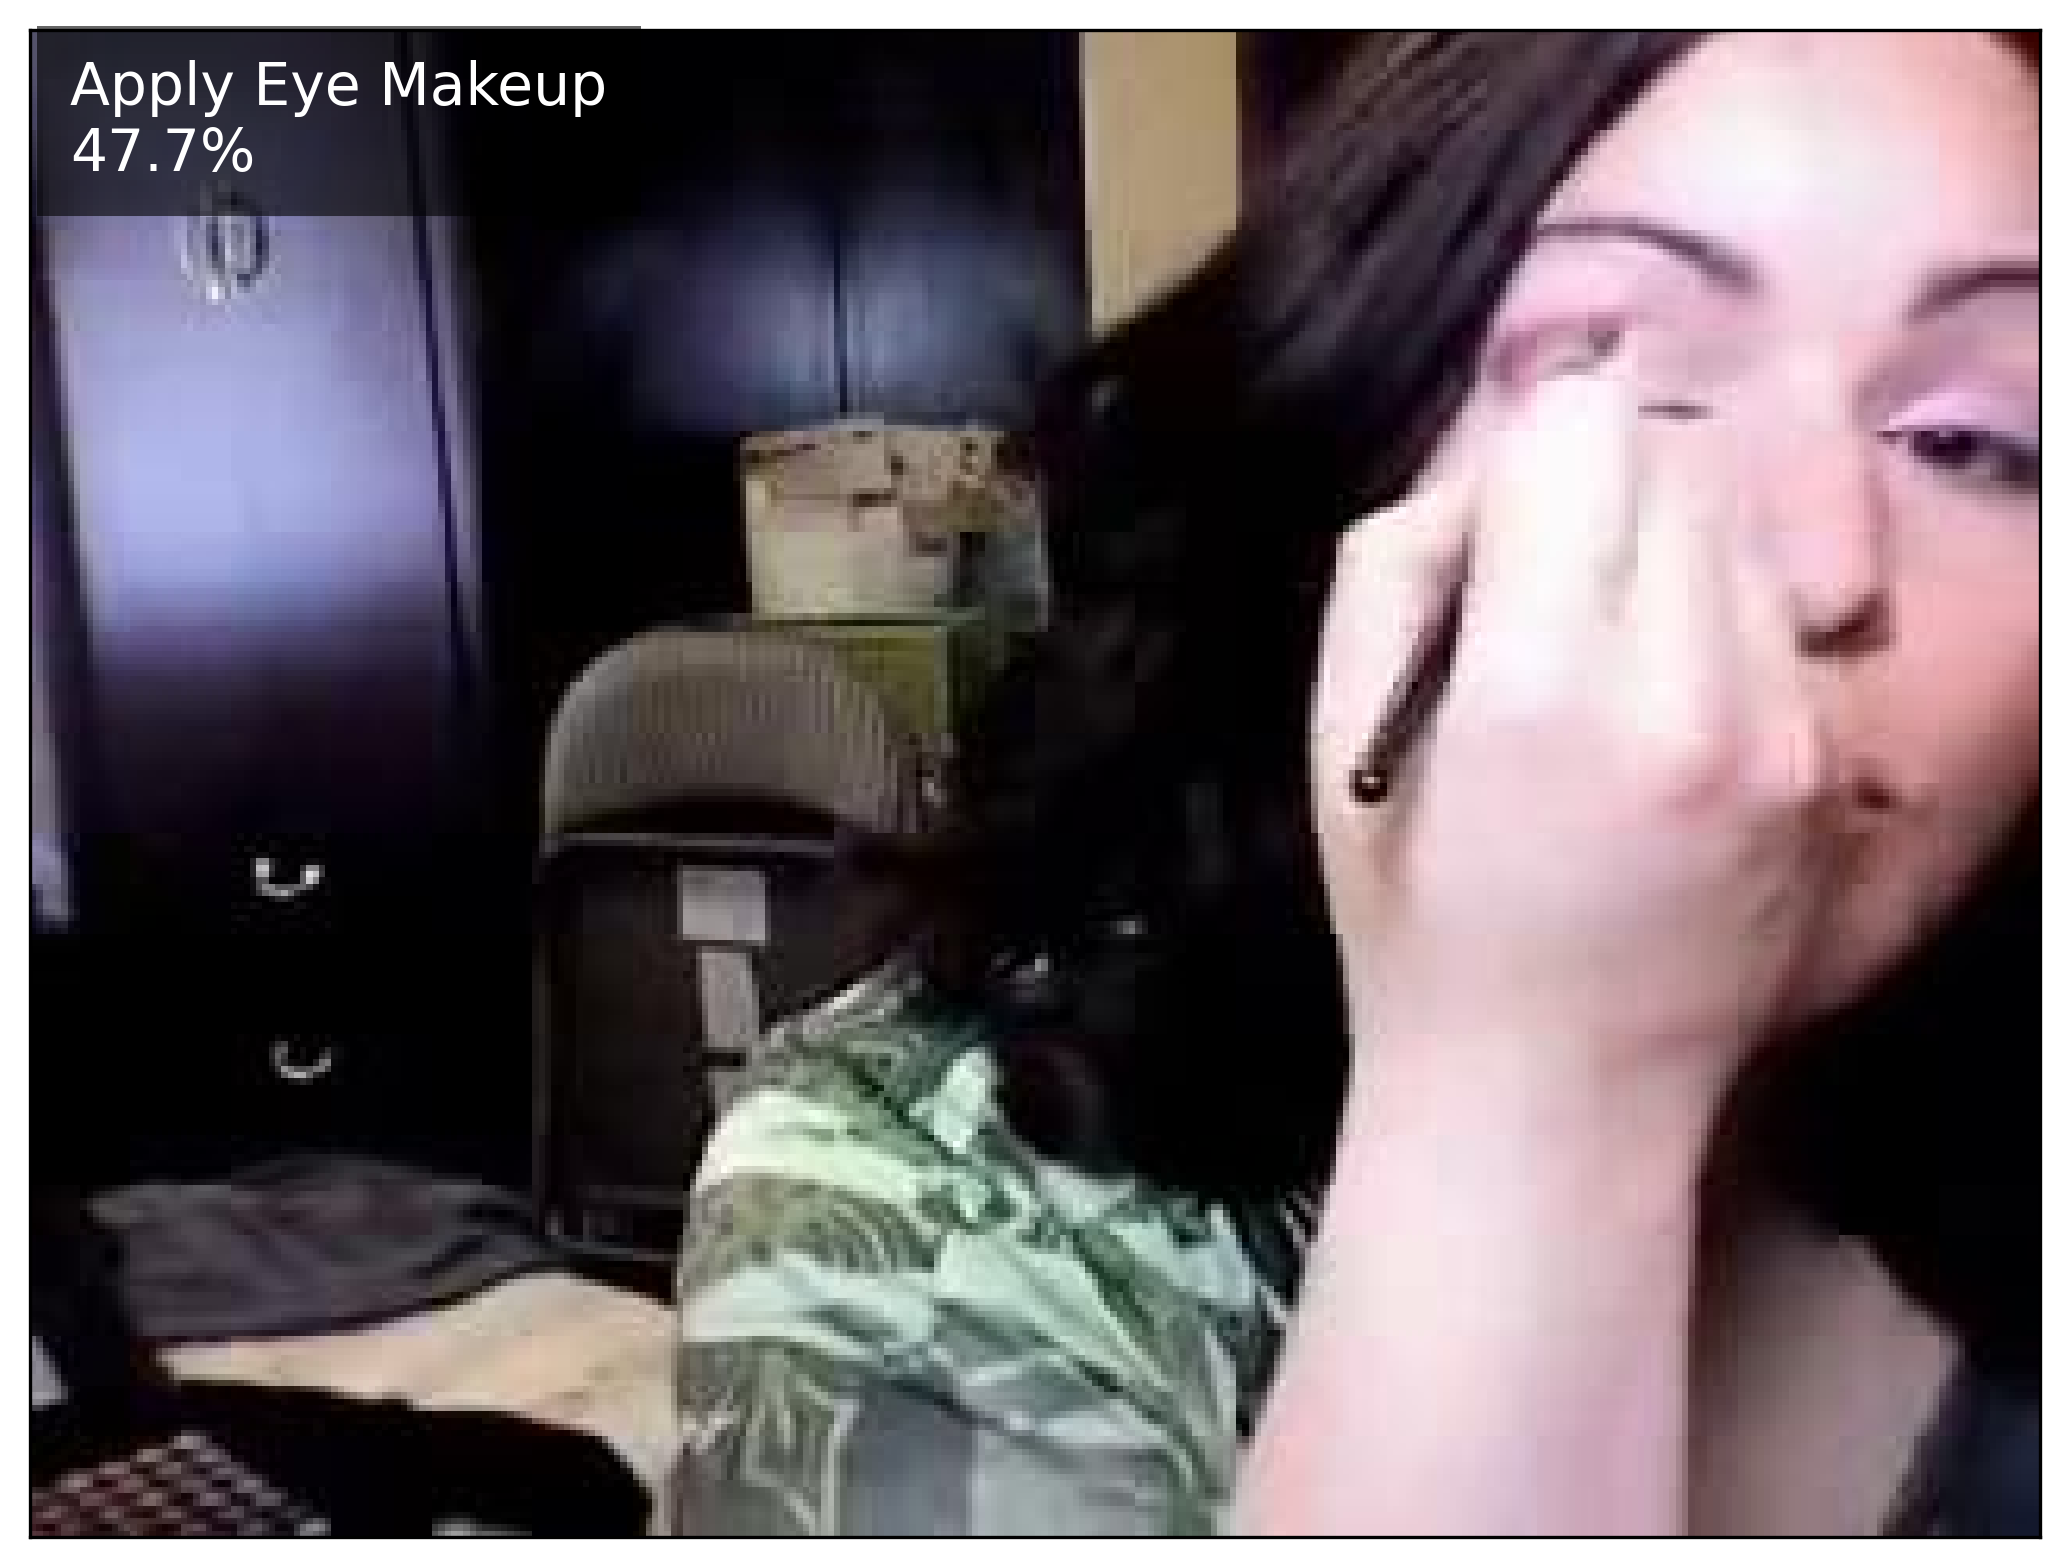

In [14]:
import glob
# Search recursively for jpg files in case they are inside class subfolders
candidates = sorted(glob.glob(f'{LOCAL_DATA}/ucf101/UCF-101-midframes/**/*.jpg', recursive=True))
DEMO_IMAGE = candidates[0]
print('Using image:', DEMO_IMAGE)

DEMO_OUT = f'{LOCAL_DEMO}/demo_output.png'

!python /content/demo.py \
    --image       "{DEMO_IMAGE}" \
    --checkpoint  "{S4_CKPT}" \
    --shvit-dir   {SHVIT_DIR} \
    --data-root   {LOCAL_DATA} \
    --output      "{DEMO_OUT}"

if os.path.exists(DEMO_OUT):
    display(Image(DEMO_OUT, width=600))

## 10. Bundle everything for download

Zips the entire `<OUT_ROOT>/Stage 4: Benchmarking and Demo/analysis/`
folder so you can download it from the Colab file browser
(right-click `analysis.zip` → Download).


In [15]:
ZIP_PATH = '/content/CV_Research_Paper_UCF101_analysis.zip'
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

# Zip the analysis subtree (results, figures, EDA, error analysis, demo)
!cd "{ANALYSIS_ROOT}" && zip -rq {ZIP_PATH} \
    results figures eda_outputs error_analysis_outputs demo_output

size_mb = os.path.getsize(ZIP_PATH) / 1e6
print(f'Bundle ready: {ZIP_PATH}  ({size_mb:.1f} MB)')
print('Right-click in the file browser to download.')


Bundle ready: /content/CV_Research_Paper_UCF101_analysis.zip  (9.9 MB)
Right-click in the file browser to download.


In [16]:
# Optional: also copy the bundle to Drive for safety
DRIVE_BUNDLE = '/content/drive/MyDrive/CV_Research_Paper_UCF101_analysis.zip'
shutil.copy(ZIP_PATH, DRIVE_BUNDLE)
print(f'Also saved to: {DRIVE_BUNDLE}')


Also saved to: /content/drive/MyDrive/CV_Research_Paper_UCF101_analysis.zip
